# Task 5 — Support Vector Machine (SVM)

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

X_train = pd.read_csv('../data/2_processed/X_train.csv')
X_test  = pd.read_csv('../data/2_processed/X_test.csv')
y_train = pd.read_csv('../data/2_processed/y_train.csv')["target"]
y_test  = pd.read_csv('../data/2_processed/y_test.csv')["target"]

## 5.1 — Kernel Comparison


In [21]:
results = []

for kernel in ['linear', 'rbf', 'poly']:
    model = SVC(kernel=kernel, C=1.0, gamma='scale', random_state=42)
    t0    = time.perf_counter()
    model.fit(X_train, y_train)
    elapsed = time.perf_counter() - t0
    acc = accuracy_score(y_test, model.predict(X_test))
    results.append({'Kernel': kernel.capitalize(), 'Accuracy': acc, 'Train Time (s)': elapsed})

df_kernels = pd.DataFrame(results)
print(df_kernels.round(4).to_string(index=False))

Kernel  Accuracy  Train Time (s)
Linear    0.9298          0.0083
   Rbf    0.9561          0.0067
  Poly    0.8860          0.0042


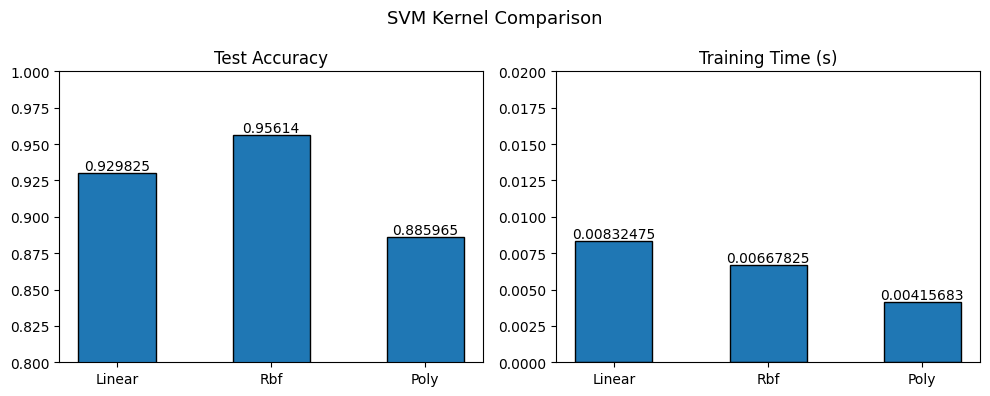

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))


for ax, col, title in zip(axes, ['Accuracy', 'Train Time (s)'], ['Test Accuracy', 'Training Time (s)']):
    bars = ax.bar(df_kernels['Kernel'], df_kernels[col], edgecolor='black', width=0.5)
    ax.set_title(title)
    ax.bar_label(bars)

axes[0].set_ylim(0.80, 1.0)
axes[1].set_ylim(0.0, 0.02)
plt.suptitle('SVM Kernel Comparison', fontsize=13)
plt.tight_layout()
plt.show()

## 5.2 — RBF Hyperparameter Grid (C x gamma)


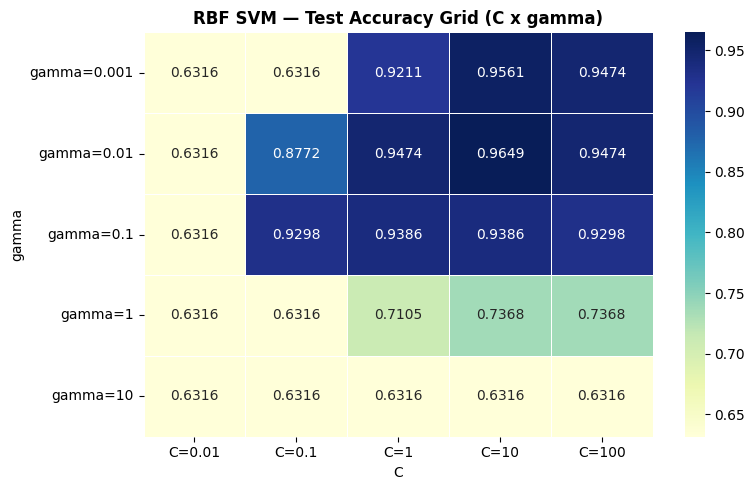

In [23]:
C_vals     = [0.01, 0.1, 1, 10, 100]
gamma_vals = [0.001, 0.01, 0.1, 1, 10]

grid = np.zeros((len(gamma_vals), len(C_vals)))

for i, g in enumerate(gamma_vals):
    for j, c in enumerate(C_vals):
        model = SVC(kernel='rbf', C=c, gamma=g, random_state=42)
        model.fit(X_train, y_train)
        grid[i, j] = accuracy_score(y_test, model.predict(X_test))

df_grid = pd.DataFrame(grid,
                        index  =[f'gamma={g}' for g in gamma_vals],
                        columns=[f'C={c}'     for c in C_vals])

plt.figure(figsize=(8, 5))
sns.heatmap(df_grid, annot=True, fmt='.4f', cmap='YlGnBu', linewidths=0.5)
plt.title('RBF SVM — Test Accuracy Grid (C x gamma)', fontweight='bold')
plt.xlabel('C')
plt.ylabel('gamma')
plt.tight_layout()
plt.show()

## 5.3 — Final Model
The RBF kernel with C=10 and gamma=0.01 is selected based on the grid above. It achieves the highest accuracy. 

In [24]:
final_svm = SVC(kernel='rbf', C=10, gamma=0.01, probability=True, random_state=42)

t0 = time.perf_counter()
final_svm.fit(X_train, y_train)
final_time = time.perf_counter() - t0

y_pred = final_svm.predict(X_test)

print(f"Training time : {final_time:.4f}s")
print(f"Test accuracy : {accuracy_score(y_test, y_pred):.4f}\n")
print(classification_report(y_test, y_pred, target_names=['Malignant', 'Benign']))

Training time : 0.0195s
Test accuracy : 0.9649

              precision    recall  f1-score   support

   Malignant       0.93      0.98      0.95        42
      Benign       0.99      0.96      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.97      0.96       114
weighted avg       0.97      0.96      0.97       114



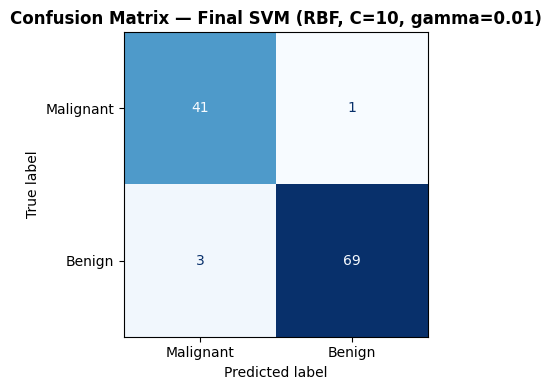

In [25]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred,
                                         display_labels=['Malignant', 'Benign'],
                                         cmap='Blues', colorbar=False, ax=ax)
ax.set_title('Confusion Matrix — Final SVM (RBF, C=10, gamma=0.01)', fontweight='bold')
plt.tight_layout()
plt.show()